<a href="https://colab.research.google.com/github/m4nn4t/stock_price_prediction/blob/MultiStockPricePrediction/MultiStock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install requests pandas tqdm -q

In [2]:
import pandas as pd
import numpy as np
import requests

from tqdm import tqdm

In [3]:
API_KEY="76e79bea0310025bde0ea382ae51ecb7cc4d561f"

START="2018-01-01"

END="2025-06-03"

In [4]:
TICKERS=[

"AAPL",
"MSFT",
"GOOGL",
"AMZN",
"META",

"NVDA",
"TSLA",
"AMD",
"NFLX",
"INTC"

]

In [5]:
all_data=[]

for ticker in tqdm(TICKERS):

    try:

        url=f"https://api.tiingo.com/tiingo/daily/{ticker}/prices"

        params={
            "startDate":START,
            "endDate":END,
            "token":API_KEY
        }

        response=requests.get(
            url,
            params=params
        )

        data=response.json()

        df=pd.DataFrame(data)

        if len(df)==0:
            continue

        df["Ticker"]=ticker

        all_data.append(df)

    except Exception as e:

        print(
            ticker,
            e
        )

100%|██████████| 10/10 [00:05<00:00,  1.74it/s]


In [6]:
master_df=pd.concat(
    all_data,
    ignore_index=True
)

master_df["date"]=pd.to_datetime(
    master_df["date"]
)

master_df.head()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor,Ticker
0,2018-01-02 00:00:00+00:00,172.26,172.30,169.26,170.16,25048048,40.268882,40.278233,39.567578,39.777969,100192192,0.0,1.0,AAPL
1,2018-01-03 00:00:00+00:00,172.23,174.55,171.96,172.53,28819653,40.261869,40.804211,40.198751,40.331999,115278612,0.0,1.0,AAPL
2,2018-01-04 00:00:00+00:00,173.03,173.47,172.08,172.54,22211345,40.448883,40.551741,40.226804,40.334337,88845380,0.0,1.0,AAPL
3,2018-01-05 00:00:00+00:00,175.00,175.37,173.05,173.44,23016177,40.909406,40.995900,40.453559,40.544728,92064708,0.0,1.0,AAPL
4,2018-01-08 00:00:00+00:00,174.35,175.61,173.93,174.35,20134092,40.757457,41.052005,40.659275,40.757457,80536368,0.0,1.0,AAPL


In [7]:
print(master_df.shape)

print(
master_df["Ticker"].nunique()
)

(18650, 14)
10


In [8]:
master_df.to_csv(
    "multi_stock_raw.csv",
    index=False
)

print(
"Saved"
)

Saved


In [9]:
master_df.shape

master_df.head()

master_df["Ticker"].value_counts()

,count
Ticker,
AAPL,1865
MSFT,1865
GOOGL,1865
AMZN,1865
META,1865
NVDA,1865
TSLA,1865
AMD,1865
NFLX,1865


FEATURE ENGINEERING

In [10]:
master_df=master_df.sort_values(
    ["Ticker","date"]
)

In [11]:
def add_indicators(df):

    df=df.copy()

    # EMA

    df["EMA_10"]=df["close"].ewm(
        span=10,
        adjust=False
    ).mean()

    df["EMA_30"]=df["close"].ewm(
        span=30,
        adjust=False
    ).mean()

    # RSI

    delta=df["close"].diff()

    gain=delta.clip(lower=0)

    loss=-delta.clip(upper=0)

    avg_gain=gain.rolling(14).mean()

    avg_loss=loss.rolling(14).mean()

    rs=avg_gain/avg_loss

    df["RSI"]=100-(100/(1+rs))

    # MACD

    ema12=df["close"].ewm(
        span=12,
        adjust=False
    ).mean()

    ema26=df["close"].ewm(
        span=26,
        adjust=False
    ).mean()

    df["MACD"]=ema12-ema26

    # Bollinger Bands

    sma20=df["close"].rolling(20).mean()

    std20=df["close"].rolling(20).std()

    df["BB_UPPER"]=sma20+(2*std20)

    df["BB_LOWER"]=sma20-(2*std20)

    # ATR

    high_low=df["high"]-df["low"]

    high_close=np.abs(
        df["high"]-df["close"].shift()
    )

    low_close=np.abs(
        df["low"]-df["close"].shift()
    )

    ranges=pd.concat(
        [
            high_low,
            high_close,
            low_close
        ],
        axis=1
    )

    true_range=np.max(
        ranges,
        axis=1
    )

    df["ATR"]=true_range.rolling(14).mean()

    return df

In [12]:
feature_df=master_df.groupby(
    "Ticker",
    group_keys=False
).apply(
    add_indicators
)

/tmp/ipykernel_800/2965470934.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


In [13]:
feature_df=feature_df.dropna()

feature_df.shape

(18460, 21)

In [14]:
feature_df.columns

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'adjClose', 'adjHigh',
       'adjLow', 'adjOpen', 'adjVolume', 'divCash', 'splitFactor', 'Ticker',
       'EMA_10', 'EMA_30', 'RSI', 'MACD', 'BB_UPPER', 'BB_LOWER', 'ATR'],
      dtype='object')

In [15]:
feature_df.to_csv(
    "multi_stock_features.csv",
    index=False
)

print("Feature dataset saved")

Feature dataset saved


In [16]:
feature_df.shape

feature_df.head()

feature_df.columns

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'adjClose', 'adjHigh',
       'adjLow', 'adjOpen', 'adjVolume', 'divCash', 'splitFactor', 'Ticker',
       'EMA_10', 'EMA_30', 'RSI', 'MACD', 'BB_UPPER', 'BB_LOWER', 'ATR'],
      dtype='object')

UNIVERSAL TRAINING DATASET

To build a scalable stock prediction platform, a universal dataset was created using historical data from ten major stocks: AAPL, MSFT, GOOGL, AMZN, META, NVDA, TSLA, AMD, NFLX, and INTC. Instead of relying solely on raw market data (Open, High, Low, Close, and Volume), several technical indicators such as EMA-10, EMA-30, RSI, MACD, Bollinger Bands, and ATR were added to capture trend, momentum, and volatility information. Each stock was assigned a unique Stock_ID, allowing the model to distinguish between different company behaviors. The dataset was then split chronologically to prevent future data leakage, ensuring a realistic forecasting setup. Using a sliding window approach, the previous 100 days of market and indicator data were used as input features to predict the next 3 days of closing prices. This process generated 13,730 training samples and 2,670 testing samples, creating a robust multi-stock dataset that enables the model to learn general market patterns rather than the behavior of a single stock, making it suitable for deployment in a real-world stock forecasting platform.

In [17]:
#creating stock ID for individual companies
from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()

feature_df["Stock_ID"]=encoder.fit_transform(
    feature_df["Ticker"]
)

feature_df[
    ["Ticker","Stock_ID"]
].drop_duplicates().sort_values(
    "Stock_ID"
)

,Ticker,Stock_ID
19,AAPL,0
13074,AMD,1
5614,AMZN,2
3749,GOOGL,3
16804,INTC,4
7479,META,5
1884,MSFT,6
14939,NFLX,7
9344,NVDA,8
11209,TSLA,9


In [18]:
FEATURE_COLUMNS=[

"open",
"high",
"low",
"close",
"volume",

"EMA_10",
"EMA_30",

"RSI",

"MACD",

"BB_UPPER",
"BB_LOWER",

"ATR",

"Stock_ID"

]

In [19]:
#normalize Features
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

feature_df[FEATURE_COLUMNS]=scaler.fit_transform(
    feature_df[FEATURE_COLUMNS]
)

In [20]:
WINDOW=100

FORECAST=3

In [21]:
X_train=[]

y_train=[]

X_test=[]

y_test=[]

In [22]:
for ticker in feature_df["Ticker"].unique():

    stock_df=feature_df[
        feature_df["Ticker"]==ticker
    ].sort_values("date")

In [23]:
    split_idx=int(
        len(stock_df)*0.8
    )

    train_df=stock_df.iloc[:split_idx]

    test_df=stock_df.iloc[split_idx:]

In [24]:
    train_values=train_df[
        FEATURE_COLUMNS
    ].values

    close_idx=FEATURE_COLUMNS.index(
        "close"
    )

In [25]:
    for i in range(
        len(train_values)-WINDOW-FORECAST
    ):

        X_train.append(
            train_values[
                i:i+WINDOW
            ]
        )

        y_train.append(
            train_values[
                i+WINDOW:
                i+WINDOW+FORECAST,
                close_idx
            ]
        )

In [26]:
    test_values=test_df[
        FEATURE_COLUMNS
    ].values

In [27]:
    for i in range(
        len(test_values)-WINDOW-FORECAST
    ):

        X_test.append(
            test_values[
                i:i+WINDOW
            ]
        )

        y_test.append(
            test_values[
                i+WINDOW:
                i+WINDOW+FORECAST,
                close_idx
            ]
        )

In [28]:
X_train=np.array(X_train)

y_train=np.array(y_train)

X_test=np.array(X_test)

y_test=np.array(y_test)

In [29]:
print("X_train:",X_train.shape)

print("y_train:",y_train.shape)

print("X_test:",X_test.shape)

print("y_test:",y_test.shape)

X_train: (1373, 100, 13)
y_train: (1373, 3)
X_test: (267, 100, 13)
y_test: (267, 3)


In [30]:
print(feature_df.shape)

print(feature_df["Ticker"].value_counts())

(18460, 22)
Ticker
AAPL     1846
AMD      1846
AMZN     1846
GOOGL    1846
INTC     1846
META     1846
MSFT     1846
NFLX     1846
NVDA     1846
TSLA     1846
Name: count, dtype: int64


In [31]:
for ticker in feature_df["Ticker"].unique():

    stock_df=feature_df[
        feature_df["Ticker"]==ticker
    ]

    print(
        ticker,
        len(stock_df)
    )

AAPL 1846
AMD 1846
AMZN 1846
GOOGL 1846
INTC 1846
META 1846
MSFT 1846
NFLX 1846
NVDA 1846
TSLA 1846


In [32]:
print(
feature_df["Ticker"].nunique()
)

10


In [33]:
print(feature_df.shape)

print(feature_df["Ticker"].nunique())

print(feature_df["Ticker"].value_counts())

(18460, 22)
10
Ticker
AAPL     1846
AMD      1846
AMZN     1846
GOOGL    1846
INTC     1846
META     1846
MSFT     1846
NFLX     1846
NVDA     1846
TSLA     1846
Name: count, dtype: int64


In [34]:
X_train=[]
y_train=[]

X_test=[]
y_test=[]

In [35]:
WINDOW=100
FORECAST=3

X_train=[]
y_train=[]

X_test=[]
y_test=[]

for ticker in feature_df["Ticker"].unique():

    stock_df=feature_df[
        feature_df["Ticker"]==ticker
    ].sort_values("date")

    split_idx=int(len(stock_df)*0.8)

    train_df=stock_df.iloc[:split_idx]

    test_df=stock_df.iloc[split_idx:]

    train_values=train_df[FEATURE_COLUMNS].values

    test_values=test_df[FEATURE_COLUMNS].values

    close_idx=FEATURE_COLUMNS.index("close")

    for i in range(len(train_values)-WINDOW-FORECAST):

        X_train.append(
            train_values[i:i+WINDOW]
        )

        y_train.append(
            train_values[
                i+WINDOW:i+WINDOW+FORECAST,
                close_idx
            ]
        )

    for i in range(len(test_values)-WINDOW-FORECAST):

        X_test.append(
            test_values[i:i+WINDOW]
        )

        y_test.append(
            test_values[
                i+WINDOW:i+WINDOW+FORECAST,
                close_idx
            ]
        )


X_train=np.array(X_train)

y_train=np.array(y_train)

X_test=np.array(X_test)

y_test=np.array(y_test)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(13730, 100, 13)
(13730, 3)
(2670, 100, 13)
(2670, 3)


Training Dataset

In [36]:
import tensorflow as tf

BATCH = 64

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(5000).batch(BATCH).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

In [37]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

model = Sequential()

model.add(
    GRU(
        128,
        return_sequences=True,
        input_shape=(100,13)
    )
)

model.add(
    Dropout(0.05)
)

model.add(
    GRU(
        64
    )
)

model.add(
    Dense(
        64,
        activation="relu"
    )
)

model.add(
    Dense(
        3
    )
)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 100, 128)       │        54,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,515 (377.01 KB)

 Trainable params: 96,515 (377.01 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5
    )

]

In [40]:
history = model.fit(

    train_ds,

    validation_data=test_ds,

    epochs=50,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0028 - mae: 0.0195 - val_loss: 1.4234e-04 - val_mae: 0.0062 - learning_rate: 0.0010
Epoch 2/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 4.1109e-04 - mae: 0.0100 - val_loss: 1.1387e-04 - val_mae: 0.0049 - learning_rate: 0.0010
Epoch 3/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 3.7757e-04 - mae: 0.0095 - val_loss: 1.0815e-04 - val_mae: 0.0043 - learning_rate: 0.0010
Epoch 4/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 3.2140e-04 - mae: 0.0083 - val_loss: 1.2046e-04 - val_mae: 0.0056 - learning_rate: 0.0010
Epoch 5/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 3.2069e-04 - mae: 0.0086 - val_loss: 1.0748e-04 - val_mae: 0.0041 - learning_rate: 0.0010
Epoch 6/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 2.8073e-04 - mae: 0.0075 - val_loss: 1.0960e-04 - val_mae: 0.0059 - learning_rate: 0.0010
Epoch 7/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 2.5970e-04 - mae: 0.0067 - val_loss: 

In [41]:
print("Best Validation Loss:", min(history.history["val_loss"]))

print("Best Validation MAE:", min(history.history["val_mae"]))

Best Validation Loss: 8.125387830659747e-05
Best Validation MAE: 0.002943385625258088


In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 100, 128)       │        54,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289,547 (1.10 MB)

 Trainable params: 96,515 (377.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 193,032 (754.04 KB)

Real-world performance measurement

In [43]:
y_pred=model.predict(X_test)

print(y_pred.shape)

print(y_test.shape)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
(2670, 3)
(2670, 3)


In [44]:
import numpy as np

close_idx=FEATURE_COLUMNS.index("close")

def inverse_close(values):

    temp=np.zeros(
        (
            len(values),
            len(FEATURE_COLUMNS)
        )
    )

    temp[:,close_idx]=values

    return scaler.inverse_transform(
        temp
    )[:,close_idx]

In [45]:
actual_flat=y_test.reshape(-1)

pred_flat=y_pred.reshape(-1)

In [46]:
actual_prices=inverse_close(
    actual_flat
)

pred_prices=inverse_close(
    pred_flat
)

In [47]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

import numpy as np


rmse=np.sqrt(
    mean_squared_error(
        actual_prices,
        pred_prices
    )
)

mae=mean_absolute_error(
    actual_prices,
    pred_prices
)

mape=np.mean(
    np.abs(
        (actual_prices-pred_prices)
        /
        actual_prices
    )
)*100

r2=r2_score(
    actual_prices,
    pred_prices
)

print("RMSE :",rmse)

print("MAE :",mae)

print("MAPE :",mape)

print("R2 :",r2)

RMSE : 33.54937300133928
MAE : 11.271267278221643
MAPE : 6.2718994001503745
R2 : 0.9818386115409562


In [48]:
actual_dir=np.sign(
    np.diff(actual_prices)
)

pred_dir=np.sign(
    np.diff(pred_prices)
)

direction_accuracy=np.mean(
    actual_dir==pred_dir
)*100

print(
    "Direction Accuracy:",
    direction_accuracy
)

Direction Accuracy: 49.7315520039955


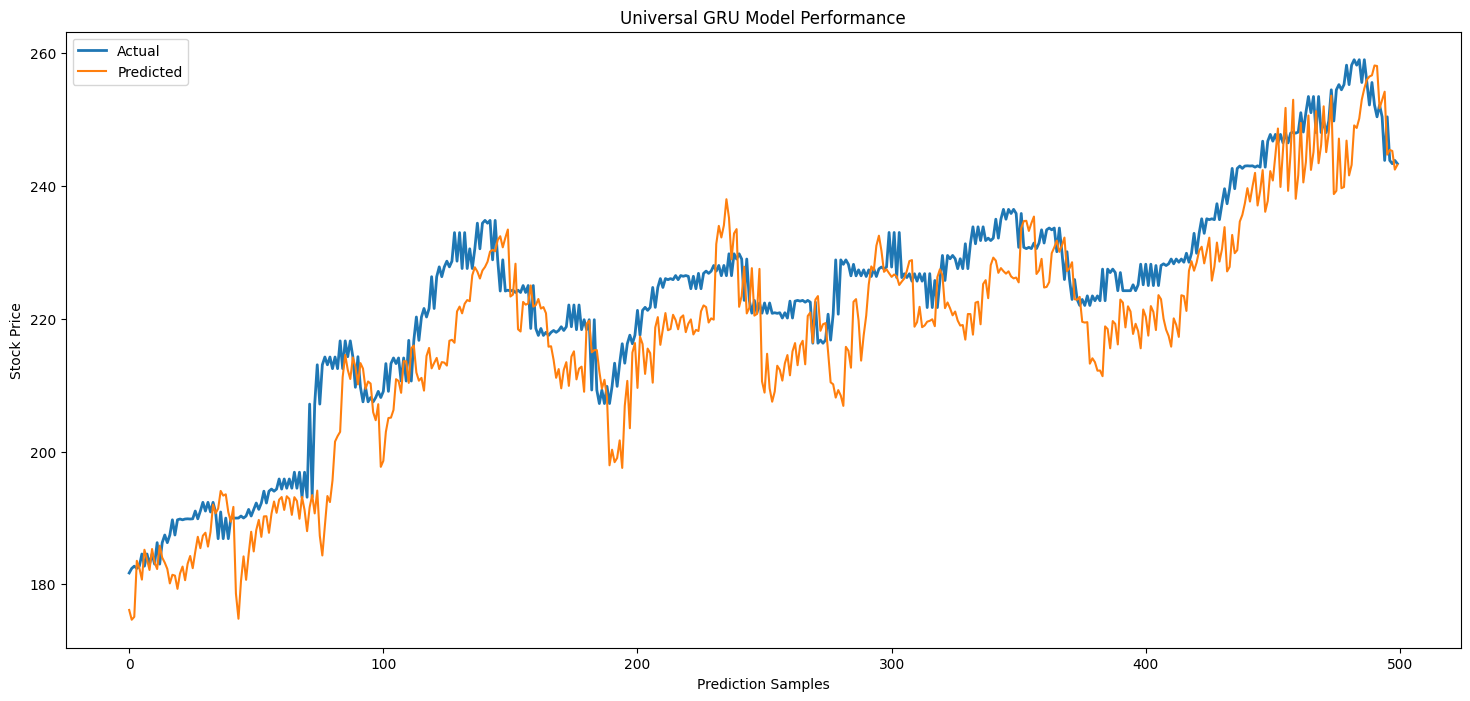

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,8))

plt.plot(
    actual_prices[:500],
    label="Actual",
    linewidth=2
)

plt.plot(
    pred_prices[:500],
    label="Predicted"
)

plt.title(
    "Universal GRU Model Performance"
)

plt.xlabel(
    "Prediction Samples"
)

plt.ylabel(
    "Stock Price"
)

plt.legend()

plt.show()

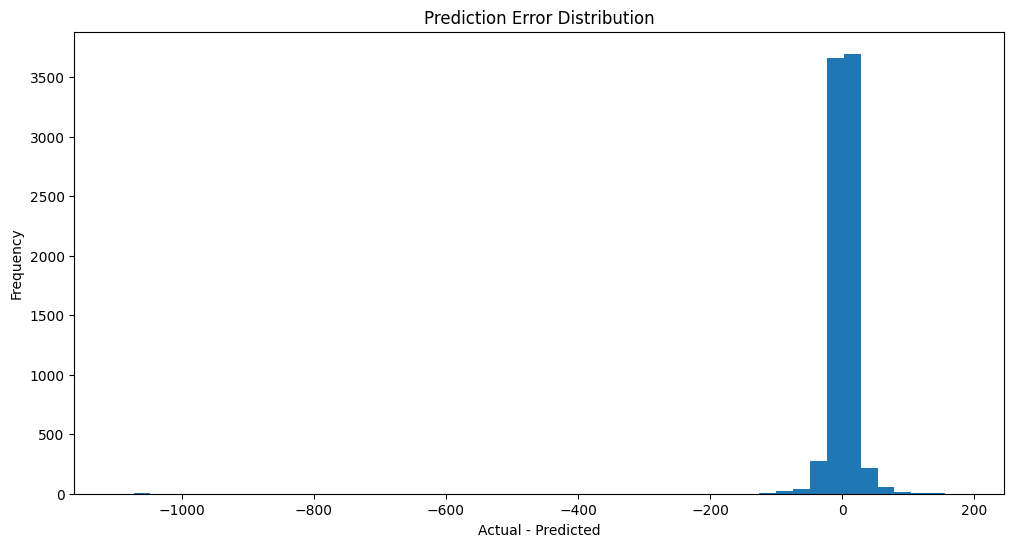

In [50]:
errors=actual_prices-pred_prices

plt.figure(figsize=(12,6))

plt.hist(
    errors,
    bins=50
)

plt.title(
    "Prediction Error Distribution"
)

plt.xlabel(
    "Actual - Predicted"
)

plt.ylabel(
    "Frequency"
)

plt.show()

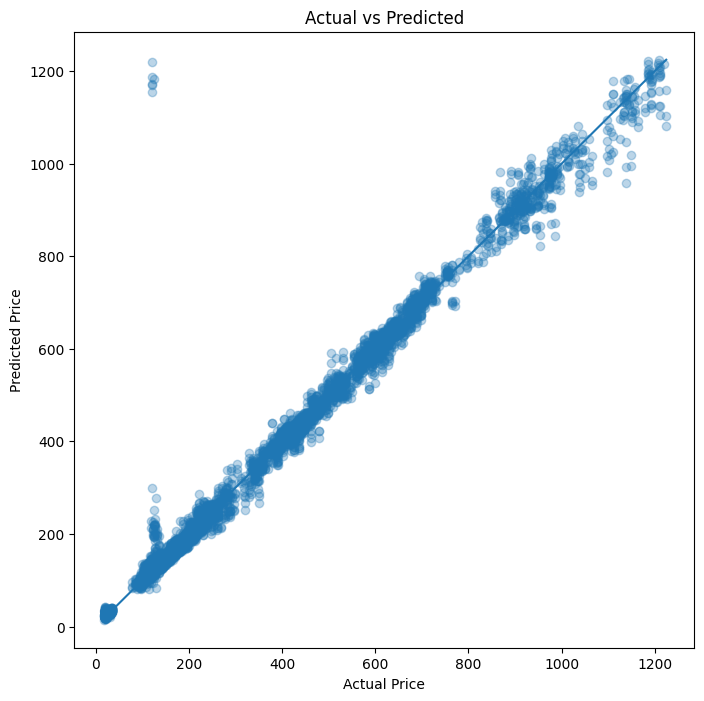

In [51]:
plt.figure(figsize=(8,8))

plt.scatter(
    actual_prices,
    pred_prices,
    alpha=0.3
)

min_val=min(
    actual_prices.min(),
    pred_prices.min()
)

max_val=max(
    actual_prices.max(),
    pred_prices.max()
)

plt.plot(
    [min_val,max_val],
    [min_val,max_val]
)

plt.xlabel(
    "Actual Price"
)

plt.ylabel(
    "Predicted Price"
)

plt.title(
    "Actual vs Predicted"
)

plt.show()

In [52]:
actual_day1=y_test[:,0]

pred_day1=y_pred[:,0]

In [53]:
actual_prices=inverse_close(actual_day1)

pred_prices=inverse_close(pred_day1)

In [54]:
actual_dir=np.sign(
    actual_prices[1:]
    -
    actual_prices[:-1]
)

pred_dir=np.sign(
    pred_prices[1:]
    -
    pred_prices[:-1]
)

direction_accuracy=np.mean(
    actual_dir==pred_dir
)*100

print(direction_accuracy)

49.11952041963282


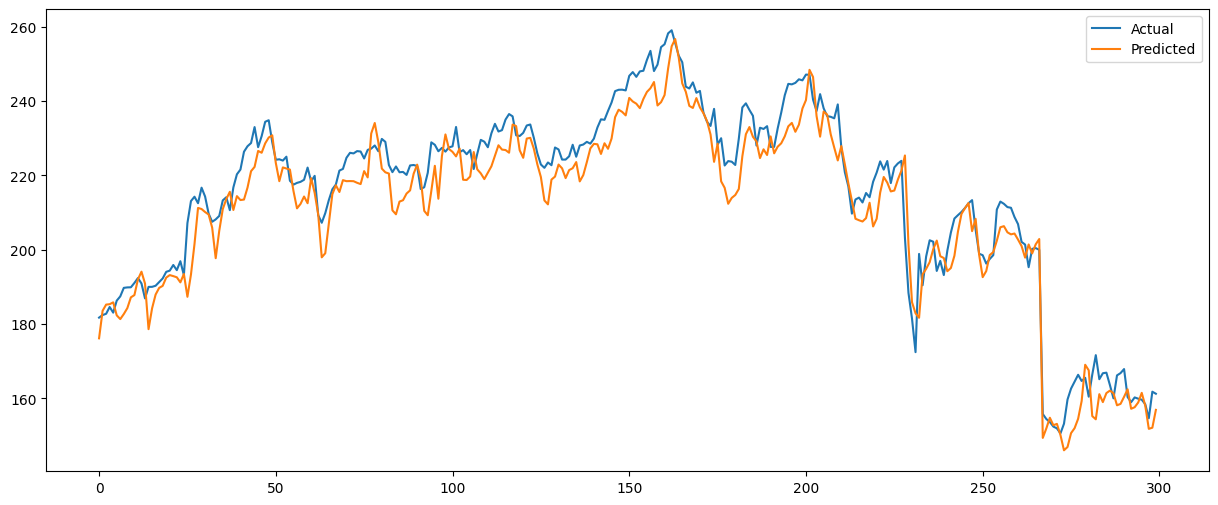

In [55]:
plt.figure(figsize=(15,6))

plt.plot(actual_prices[:300],label="Actual")

plt.plot(pred_prices[:300],label="Predicted")

plt.legend()

plt.show()

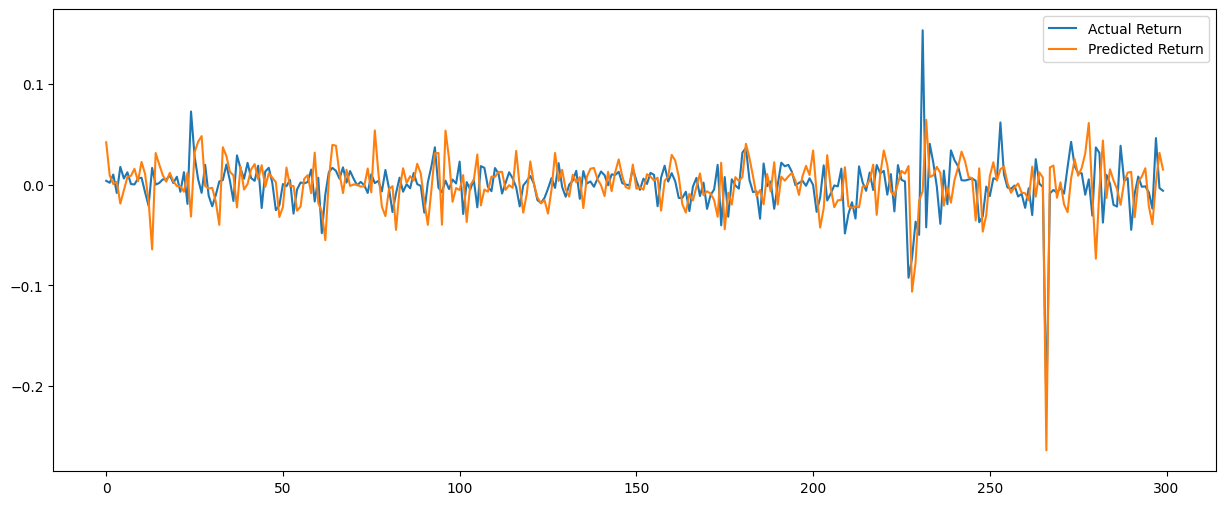

In [56]:
actual_return=(actual_prices[1:]-actual_prices[:-1])/actual_prices[:-1]

pred_return=(pred_prices[1:]-pred_prices[:-1])/pred_prices[:-1]

plt.figure(figsize=(15,6))

plt.plot(actual_return[:300],label="Actual Return")

plt.plot(pred_return[:300],label="Predicted Return")

plt.legend()

plt.show()

Adding features RETURN_1D,RETURN_5D,MOMENTUM_10,VOLATILITY_10 to increase direction accuracy.

In [57]:
feature_df=feature_df.sort_values(
    ["Ticker","date"]
)

In [58]:
def add_direction_features(df):

    df=df.copy()

    df["RETURN_1D"]=df["close"].pct_change()

    df["RETURN_5D"]=df["close"].pct_change(5)

    df["MOMENTUM_10"]=df["close"]-df["close"].shift(10)

    df["VOLATILITY_10"]=df["RETURN_1D"].rolling(10).std()

    return df

In [59]:
feature_df=feature_df.groupby(
    "Ticker",
    group_keys=False
).apply(
    add_direction_features
)

/tmp/ipykernel_800/2381322042.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


In [60]:
feature_df=feature_df.dropna()

print(feature_df.shape)

(18345, 26)


In [61]:
FEATURE_COLUMNS=[

"open",
"high",
"low",
"close",
"volume",

"EMA_10",
"EMA_30",

"RSI",

"MACD",

"BB_UPPER",
"BB_LOWER",

"ATR",

"RETURN_1D",
"RETURN_5D",

"MOMENTUM_10",

"VOLATILITY_10",

"Stock_ID"

]

In [62]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

feature_df[FEATURE_COLUMNS]=scaler.fit_transform(
    feature_df[FEATURE_COLUMNS]
)

In [63]:
WINDOW=100
FORECAST=3

X_train=[]
y_train=[]

X_test=[]
y_test=[]

for ticker in feature_df["Ticker"].unique():

    stock_df=feature_df[
        feature_df["Ticker"]==ticker
    ].sort_values("date")

    split_idx=int(len(stock_df)*0.8)

    train_df=stock_df.iloc[:split_idx]

    test_df=stock_df.iloc[split_idx:]

    train_values=train_df[
        FEATURE_COLUMNS
    ].values

    test_values=test_df[
        FEATURE_COLUMNS
    ].values

    close_idx=FEATURE_COLUMNS.index(
        "close"
    )

    for i in range(
        len(train_values)-WINDOW-FORECAST
    ):

        X_train.append(
            train_values[
                i:i+WINDOW
            ]
        )

        y_train.append(
            train_values[
                i+WINDOW:
                i+WINDOW+FORECAST,
                close_idx
            ]
        )

    for i in range(
        len(test_values)-WINDOW-FORECAST
    ):

        X_test.append(
            test_values[
                i:i+WINDOW
            ]
        )

        y_test.append(
            test_values[
                i+WINDOW:
                i+WINDOW+FORECAST,
                close_idx
            ]
        )

X_train=np.array(X_train)

y_train=np.array(y_train)

X_test=np.array(X_test)

y_test=np.array(y_test)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(13638, 100, 17)
(13638, 3)
(2647, 100, 17)
(2647, 3)


In [64]:
import tensorflow as tf

BATCH=64

train_ds=tf.data.Dataset.from_tensor_slices(
    (X_train,y_train)
).shuffle(5000).batch(BATCH).prefetch(
    tf.data.AUTOTUNE
)

test_ds=tf.data.Dataset.from_tensor_slices(
    (X_test,y_test)
).batch(BATCH).prefetch(
    tf.data.AUTOTUNE
)

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU,Dense,Dropout

model=Sequential()

model.add(
    GRU(
        128,
        return_sequences=True,
        input_shape=(100,17)
    )
)

model.add(
    Dropout(0.05)
)

model.add(
    GRU(
        64
    )
)

model.add(
    Dense(
        64,
        activation="relu"
    )
)

model.add(
    Dense(
        3
    )
)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 100, 128)       │        56,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,051 (383.01 KB)

 Trainable params: 98,051 (383.01 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

callbacks=[

    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5
    )

]

In [67]:
history=model.fit(

    train_ds,

    validation_data=test_ds,

    epochs=50,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0032 - mae: 0.0215 - val_loss: 1.5379e-04 - val_mae: 0.0070 - learning_rate: 0.0010
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4.2154e-04 - mae: 0.0109 - val_loss: 1.3149e-04 - val_mae: 0.0059 - learning_rate: 0.0010
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3.5793e-04 - mae: 0.0096 - val_loss: 2.3865e-04 - val_mae: 0.0123 - learning_rate: 0.0010
Epoch 4/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3.2870e-04 - mae: 0.0090 - val_loss: 1.0111e-04 - val_mae: 0.0047 - learning_rate: 0.0010
Epoch 5/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3.1640e-04 - mae: 0.0084 - val_loss: 8.9747e-05 - val_mae: 0.0037 - learning_rate: 0.0010
Epoch 6/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 2.9248e-04 - mae: 0.0076 - val_loss: 1.4731e-04 - val_mae: 0.0083 - learning_rate: 0.0010
Epoch 7/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.5780e-04 - mae: 0.0068 - val_loss: 

In [68]:
print(
    "Best Validation Loss:",
    min(history.history["val_loss"])
)

print(
    "Best Validation MAE:",
    min(history.history["val_mae"])
)

Best Validation Loss: 7.788335642544553e-05
Best Validation MAE: 0.0025786040350794792


In [69]:
y_pred=model.predict(X_test)

print(y_pred.shape)

print(y_test.shape)

83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
(2647, 3)
(2647, 3)


In [70]:
close_idx=FEATURE_COLUMNS.index("close")

def inverse_close(values):

    temp=np.zeros(
        (
            len(values),
            len(FEATURE_COLUMNS)
        )
    )

    temp[:,close_idx]=values

    return scaler.inverse_transform(
        temp
    )[:,close_idx]

In [71]:
actual_flat=y_test.reshape(-1)

pred_flat=y_pred.reshape(-1)

In [72]:
actual_prices=inverse_close(
    actual_flat
)

pred_prices=inverse_close(
    pred_flat
)

In [73]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

rmse=np.sqrt(
    mean_squared_error(
        actual_prices,
        pred_prices
    )
)

mae=mean_absolute_error(
    actual_prices,
    pred_prices
)

mape=np.mean(
    np.abs(
        (actual_prices-pred_prices)
        /
        actual_prices
    )
)*100

r2=r2_score(
    actual_prices,
    pred_prices
)

print("RMSE :",rmse)

print("MAE :",mae)

print("MAPE :",mape)

print("R2 :",r2)

RMSE : 0.008825154996680963
MAE : 0.0025845180794013415
MAPE : 6.402601448171774
R2 : 0.9825976753953061


In [74]:
actual_day1=y_test[:,0]

pred_day1=y_pred[:,0]

actual_prices_day1=inverse_close(
    actual_day1
)

pred_prices_day1=inverse_close(
    pred_day1
)

actual_dir=np.sign(
    actual_prices_day1[1:]
    -
    actual_prices_day1[:-1]
)

pred_dir=np.sign(
    pred_prices_day1[1:]
    -
    pred_prices_day1[:-1]
)

direction_accuracy=np.mean(
    actual_dir==pred_dir
)*100

print(
    "Direction Accuracy:",
    direction_accuracy
)

Direction Accuracy: 49.1307634164777


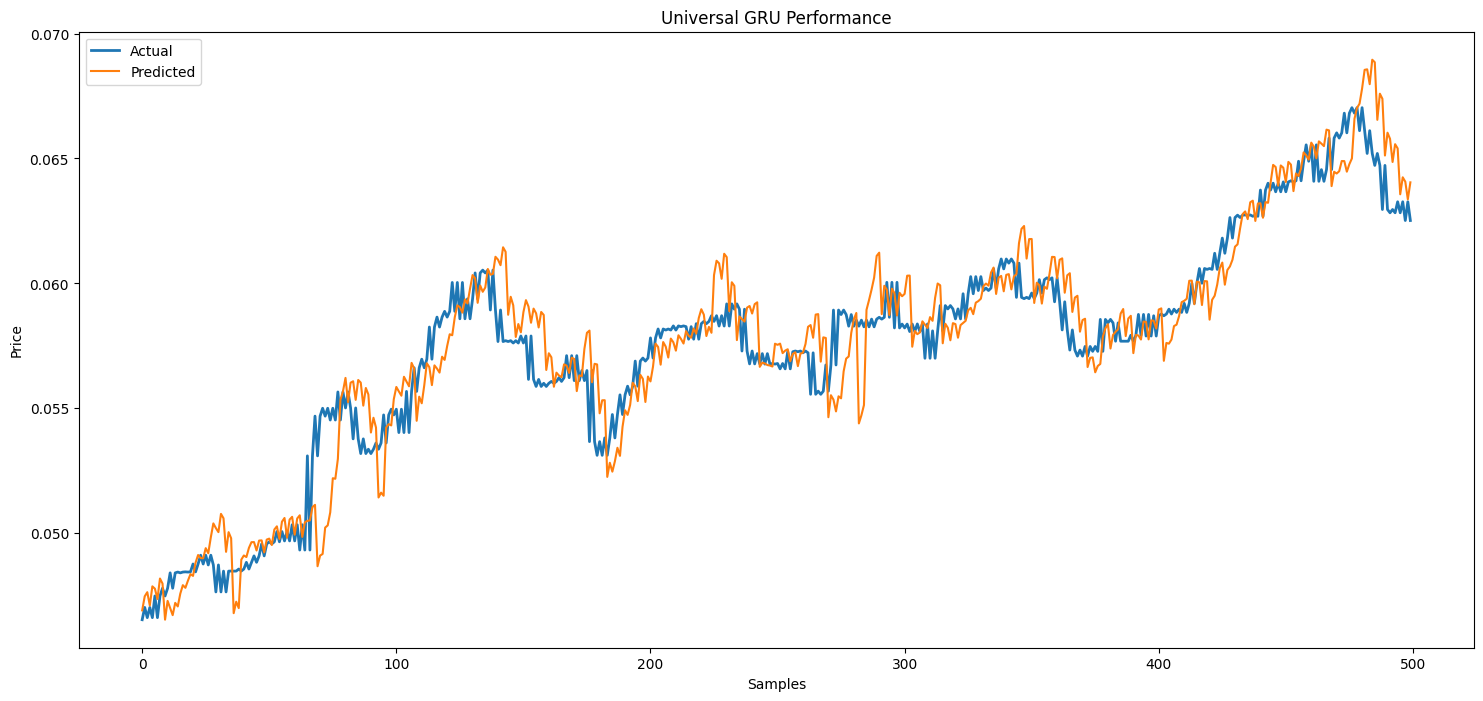

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,8))

plt.plot(
    actual_prices[:500],
    label="Actual",
    linewidth=2
)

plt.plot(
    pred_prices[:500],
    label="Predicted"
)

plt.title(
    "Universal GRU Performance"
)

plt.xlabel(
    "Samples"
)

plt.ylabel(
    "Price"
)

plt.legend()

plt.show()